## Flight Price: Prediction Data set 

got it from kaggle 


Dataset contains information about flight booking options from the website Easemytrip for flight travel between India's top 6 metro cities. There are 300261 datapoints and 11 features in the cleaned dataset.

# FEATURES

The various features of the cleaned dataset are explained below:
1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.
2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.
3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.
4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.
5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.
6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.
7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.
8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.
9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.
10)Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.

## Output 

11) Price: Target variable stores information of the ticket price.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_excel("/home/aizen/AI_ML/14.Exploratory_Data_Analysis_EDA/flight_price.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
# We will clean data ( we already did and learn clean in Pandas ( see those files too ) ) , the Feature Engineer it and then process it for ML

# take column by column every feature and clean it 

In [3]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [4]:
## get Basic Info 
df.info()   # see there is no NULL values   ,, All features are Object or String TYpe  ( we need to convert them too)

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 1.8 MB


In [5]:
df.describe() # only one nu,erical COl

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [6]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
# Feature Eng Date_of_journy col 1st 
# separete day/ month and year 

df["Date"] = df["Date_of_Journey"].str.split('/').str[0] # take 1st element and store in date ( i.e 24/03/2019   after split on '/'   it is : 24 03 2019 at id= x 0 , 1 ,2 )  
df["Month"] = df["Date_of_Journey"].str.split("/").str[1]
df["Year"]  = df["Date_of_Journey"].str.split("/").str[2]


print(df.info())
# Now convert them into Numerical type as they are still string type

df["Date"] = df["Date"].astype("Int8")
df["Month"] = df["Month"].astype("Int8")
df["Year"] =  df["Year"].astype("Int16")




<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  str   
 1   Date_of_Journey  10683 non-null  str   
 2   Source           10683 non-null  str   
 3   Destination      10683 non-null  str   
 4   Route            10682 non-null  str   
 5   Dep_Time         10683 non-null  str   
 6   Arrival_Time     10683 non-null  str   
 7   Duration         10683 non-null  str   
 8   Total_Stops      10682 non-null  str   
 9   Additional_Info  10683 non-null  str   
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  object
 12  Month            10683 non-null  object
 13  Year             10683 non-null  object
dtypes: int64(1), object(3), str(10)
memory usage: 2.0+ MB
None


In [8]:
df.info() # new Features are now INt 

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
 11  Date             10683 non-null  Int8 
 12  Month            10683 non-null  Int8 
 13  Year             10683 non-null  Int16
dtypes: Int16(1), Int8(2), int64(1), str(10)
memory usage: 1.9 MB


In [9]:
# Now drop Date_of_Journey COl as we have made numweic format of it 

df.drop("Date_of_Journey", axis = 1 , inplace=True)

In [10]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [11]:
# Now Arrival_time 
# take hr and mint from col and ignore date in it 
# as its wriiten like 10:35 20june 1st lets split it and take only time section then split time section into two

df["Arrival_Time"] = df["Arrival_Time"].apply(lambda x: x.split(" ")[0]) # here we take only time section 

# now arrival_time is like this 10:35   now we split this string in two i.e hour and min

df["Arrival_Hour"] = df["Arrival_Time"].str.split(":").str[0]
df["Arrival_Min"] = df["Arrival_Time"].str.split(":").str[1]


# Now type caste them into int 

df["Arrival_Hour"] = df["Arrival_Hour"].astype("Int16")
df["Arrival_Min"] = df["Arrival_Min"].astype("Int8")

# drop the col 

df.drop("Arrival_Time" , axis = 1, inplace=True)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Source           10683 non-null  str  
 2   Destination      10683 non-null  str  
 3   Route            10682 non-null  str  
 4   Dep_Time         10683 non-null  str  
 5   Duration         10683 non-null  str  
 6   Total_Stops      10682 non-null  str  
 7   Additional_Info  10683 non-null  str  
 8   Price            10683 non-null  int64
 9   Date             10683 non-null  Int8 
 10  Month            10683 non-null  Int8 
 11  Year             10683 non-null  Int16
 12  Arrival_Hour     10683 non-null  Int16
 13  Arrival_Min      10683 non-null  Int8 
dtypes: Int16(2), Int8(3), int64(1), str(8)
memory usage: 1.6 MB


In [13]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882,9,6,2019,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302,1,3,2019,21,35


In [14]:
# Now Handle Departure Time col : Dep_Time

df["Dep_Hour"] = df["Dep_Time"].str.split(":").str[0].astype("int8")
df["Dep_Min"] = df["Dep_Time"].str.split(":").str[1].astype("int8")

# drop col 

df.drop("Dep_Time", axis= 1 , inplace= True)

In [15]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


In [16]:
# NOw Categorical COl i.e Total_stops 

df["Total_Stops"].unique()

# non-stop means plane doesnt stop  : cheap price
# 1 stop : price inc
# 2 stop : price in more    
# 3, 4 : inc more 

# also have null values


<ArrowStringArray>
['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops']
Length: 6, dtype: str

In [17]:
# check nan
df[df["Total_Stops"].isna()]

# only one nan

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min
9039,Air India,Delhi,Cochin,NaN,23h 40m,NaN,No info,7480,6,5,2019,9,25,9,45


In [18]:
# fill nan with mode

df["Total_Stops"] =  df["Total_Stops"].fillna(df["Total_Stops"].mode()[0])  # replace nan with most frequent value 
df["Total_Stops"].isna().sum() # now we have no nan value 

np.int64(0)

In [19]:
# Now chnage this col in numerical ;; non_stop with 0 , 1 stop with 1 , 2 stop with 2 , 3 stop with 3 etc
# us map()

df["Total_Stops"] = df["Total_Stops"].map({"non-stop" : 0 , "1 stop" : 1, "2 stops" : 2, "3 stops" : 3, "4 stops" : 4})

In [20]:
df.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1,No info,13302,1,3,2019,21,35,16,50


In [ ]:
# Now Route Col : it is also Categorica
# we have no use for it and won't affecy ML model so drop route 
# as it shows souce and destiniation and Both already have its owns cols 

df.drop("Route", axis = 1 , inplace= True)

In [22]:
df.head()

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302,1,3,2019,21,35,16,50


In [50]:
# NOw Handle Duration COl seprate Hr and min

df["Duration_hr"] = df["Duration"].str.split(" ").str[0].str.split("h").str[0]    # 2h 50m  1st split on space so 0: 2h , 1:50m -- then choose idx 0 ( 2h ) then split on 'h' so 0:2 and 1:h we choose idx 0 that is nmbr 
df["Duration_min"] = df["Duration"].str.split(" ").str[1].str.split("m").str[0]   

# see that Duration_min has some nan values Handle them
print ( df["Duration_min"].isna().sum() )

# Handle These Values
df["Duration_min"] = df["Duration_min"].fillna(0)  # fill missing Data with zero

# Now we need to convert these row into Int type 
# but Duration hr has one pblm there is one "5m" value 
# see below we need to handle that 1st 

df["Duration_hr"] = df["Duration_hr"].replace("5m", 0) # now it is handles 


# Now Converting THe TYpe 
df["Duration_hr"] = df["Duration_hr"].astype("int8")
df["Duration_min"] = df["Duration_min"].astype("int8")
 

# dop Duration

df.drop("Duration", axis=1 , inplace= True)


1032


In [40]:
print(df["Duration_hr"].unique())

['2' '7' '19' '5' '4' '15' '21' '25' '13' '12' '26' '22' '23' '20' '10'
 '6' '11' '8' '16' '3' '27' '1' '14' '9' '18' '17' '24' '30' '28' '29'
 '37' '34' '38' '35' '36' '47' '33' '32' '31' '42' '39' '5m' '41' '40']


In [51]:
# Now checking 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Source           10683 non-null  str  
 2   Destination      10683 non-null  str  
 3   Total_Stops      10683 non-null  int64
 4   Additional_Info  10683 non-null  str  
 5   Price            10683 non-null  int64
 6   Date             10683 non-null  Int8 
 7   Month            10683 non-null  Int8 
 8   Year             10683 non-null  Int16
 9   Arrival_Hour     10683 non-null  Int16
 10  Arrival_Min      10683 non-null  Int8 
 11  Dep_Hour         10683 non-null  int8 
 12  Dep_Min          10683 non-null  int8 
 13  Duration_hr      10683 non-null  int8 
 14  Duration_min     10683 non-null  int8 
dtypes: Int16(2), Int8(3), int64(2), int8(4), str(4)
memory usage: 1.0 MB


In [52]:
df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_hr,Duration_min
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,13,15,5,50,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,4,25,9,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,23,30,18,5,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,21,35,16,50,4,45


In [ ]:
# Now there are few Categorical col that can't be converted to numerical that above   ( 'Airline', 'Source', 'Destination' )
# we will use OneHotEncoding to COnvert them

from sklearn.preprocessing import OneHotEncoder

In [47]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Date', 'Month', 'Year', 'Arrival_Hour',
       'Arrival_Min', 'Dep_Hour', 'Dep_Min', 'Duration_hr', 'Duration_min'],
      dtype='str')

In [ ]:

encoder = OneHotEncoder(handle_unknown="ignore" , sparse_output= False)

# now encode them  fit_transfrom
encoded_features = encoder.fit_transform(df[['Airline', 'Source', 'Destination']])

print( encoded_features)

df_encoded_features = pd.DataFrame(
    encoded_features,
    columns= encoder.get_feature_names_out()
)



df_encoded_features  # now merge this data frame with above one and drop the cols in og df that ewe encoded

[[0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]]


,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#1. droping ' Airline', 'Source', 'Destination'
#2 merge og df and encoded_df

df.drop(['Airline', 'Source', 'Destination'] , axis= 1 , inplace= True)

# step 1 completed

In [64]:
df

,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_hr,Duration_min
0,0,No info,3897,24,3,2019,1,10,22,20,2,50
1,2,No info,7662,1,5,2019,13,15,5,50,7,25
2,2,No info,13882,9,6,2019,4,25,9,25,19,0
3,1,No info,6218,12,5,2019,23,30,18,5,5,25
4,1,No info,13302,1,3,2019,21,35,16,50,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,No info,4107,9,4,2019,22,25,19,55,2,30
10679,0,No info,4145,27,4,2019,23,20,20,45,2,35
10680,0,No info,7229,27,4,2019,11,20,8,20,3,0
10681,0,No info,12648,1,3,2019,14,10,11,30,2,40


In [67]:
# step 2  Merge both dfs
df = pd.concat( [ df, df_encoded_features ], axis= 1)

df

,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,No info,3897,24,3,2019,1,10,22,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,No info,7662,1,5,2019,13,15,5,50,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,No info,13882,9,6,2019,4,25,9,25,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,No info,6218,12,5,2019,23,30,18,5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,No info,13302,1,3,2019,21,35,16,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,No info,4107,9,4,2019,22,25,19,55,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0,No info,4145,27,4,2019,23,20,20,45,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,0,No info,7229,27,4,2019,11,20,8,20,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,0,No info,12648,1,3,2019,14,10,11,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# drop additional INfo col 

df.drop("Additional_Info" , axis= 1 , inplace= True)

In [71]:
df

,Total_Stops,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_hr,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,1,10,22,20,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,7662,1,5,2019,13,15,5,50,7,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,13882,9,6,2019,4,25,9,25,19,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,6218,12,5,2019,23,30,18,5,5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,13302,1,3,2019,21,35,16,50,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,4107,9,4,2019,22,25,19,55,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0,4145,27,4,2019,23,20,20,45,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,0,7229,27,4,2019,11,20,8,20,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,0,12648,1,3,2019,14,10,11,30,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 57 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Total_Stops                                10683 non-null  int64  
 1   Price                                      10683 non-null  int64  
 2   Date                                       10683 non-null  Int8   
 3   Month                                      10683 non-null  Int8   
 4   Year                                       10683 non-null  Int16  
 5   Arrival_Hour                               10683 non-null  Int16  
 6   Arrival_Min                                10683 non-null  Int8   
 7   Dep_Hour                                   10683 non-null  int8   
 8   Dep_Min                                    10683 non-null  int8   
 9   Duration_hr                                10683 non-null  int8   
 10  Duration_min                     

In [73]:
df.describe()

,Total_Stops,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_hr,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
count,10683.000000,10683.000000,10683.0,10683.0,10683.0,10683.0,10683.0,10683.000000,10683.000000,10683.000000,...,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000
mean,0.824207,9087.064121,13.508378,4.708602,2019.0,13.348778,24.69063,12.490686,24.411214,10.246092,...,0.035664,0.424693,0.268745,0.065244,0.268745,0.424693,0.118412,0.065244,0.035664,0.087241
std,0.675199,4611.359167,8.479277,1.164357,0.0,6.859125,16.506036,5.748650,18.767980,8.495414,...,0.185460,0.494320,0.443328,0.246967,0.443328,0.494320,0.323111,0.246967,0.185460,0.282202
min,0.000000,1759.000000,1.0,3.0,2019.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5277.000000,6.0,3.0,2019.0,8.0,10.0,8.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,8372.000000,12.0,5.0,2019.0,14.0,25.0,11.000000,25.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,12373.000000,21.0,6.0,2019.0,19.0,35.0,18.000000,40.000000,15.000000,...,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,4.000000,79512.000000,27.0,6.0,2019.0,23.0,55.0,23.000000,55.000000,47.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Note 

##  we dont need to apply undersampling , oversamping and SMOTE B/c the output feature "price" s a continuous numerical value.

> it a `Regression` problem not `Classificaion` 


> SMOTE etc are used mainly in classification Problems



<Axes: ylabel='Price'>

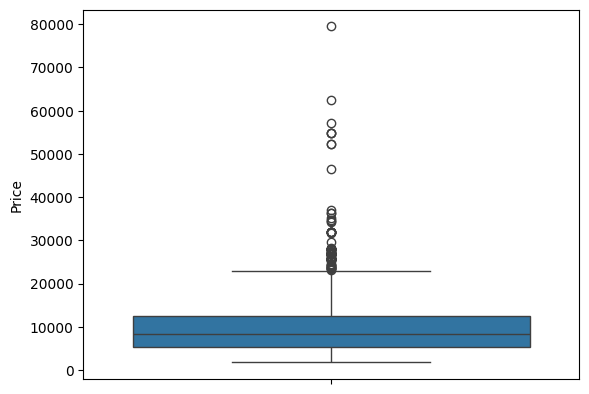

In [74]:
import seaborn as sns
sns.boxplot(df["Price"])

In [75]:
# See Price has many Outliers Remove it using 5 numr Summery 

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(lower_limit)
print(upper_limit)


df = df[(df["Price"] >= lower_limit) & 
        (df["Price"] <= upper_limit)]

-5367.0
23017.0


In [76]:
df

,Total_Stops,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_hr,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,1,10,22,20,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,7662,1,5,2019,13,15,5,50,7,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,13882,9,6,2019,4,25,9,25,19,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,6218,12,5,2019,23,30,18,5,5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,13302,1,3,2019,21,35,16,50,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,4107,9,4,2019,22,25,19,55,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0,4145,27,4,2019,23,20,20,45,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,0,7229,27,4,2019,11,20,8,20,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,0,12648,1,3,2019,14,10,11,30,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


<Axes: ylabel='Price'>

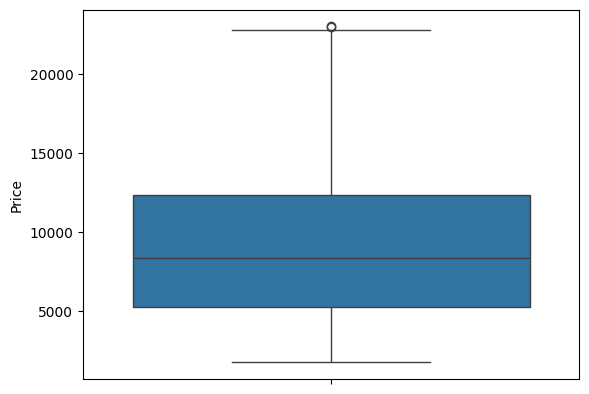

In [77]:
import seaborn as sns
sns.boxplot(df["Price"])

In [ ]:
# now we are good 

# Making This Ready For ML pipe LIne

- Copy this into new DF  i.e `df_ml = df.copy()`
- Drop Unneccessary Cols  if exita

In [78]:
df_ml = df.copy()

In [79]:
df_ml

,Total_Stops,Price,Date,Month,Year,Arrival_Hour,Arrival_Min,Dep_Hour,Dep_Min,Duration_hr,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,1,10,22,20,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,7662,1,5,2019,13,15,5,50,7,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,13882,9,6,2019,4,25,9,25,19,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,6218,12,5,2019,23,30,18,5,5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,13302,1,3,2019,21,35,16,50,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,4107,9,4,2019,22,25,19,55,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10679,0,4145,27,4,2019,23,20,20,45,2,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
10680,0,7229,27,4,2019,11,20,8,20,3,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10681,0,12648,1,3,2019,14,10,11,30,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [80]:
# Split X and Y 

X = df_ml.drop("Price", axis=1)
y = df_ml["Price"]

In [ ]:
# Now you can apply and Model